<a href="https://colab.research.google.com/github/gabrieldanho9988-sys/Project_Synthetic-Aperture-Radar-SAR-Super-Resolution-SR-using-AI-.ipynb/blob/main/Project_Synthetic_Aperture_Radar_(SAR)_Super_Resolution_(SR)_using_AI_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Preprocessing

Targeting actual scientific data asset: HH
Downloading... (This might take a minute depending on file size)
Loading image from: capella_data/CAPELLA_C13_SP_GEO_HH_20251112022441_20251112022453.tif
Full image shape is: 46671x51171
Extracted patch max value: 65535


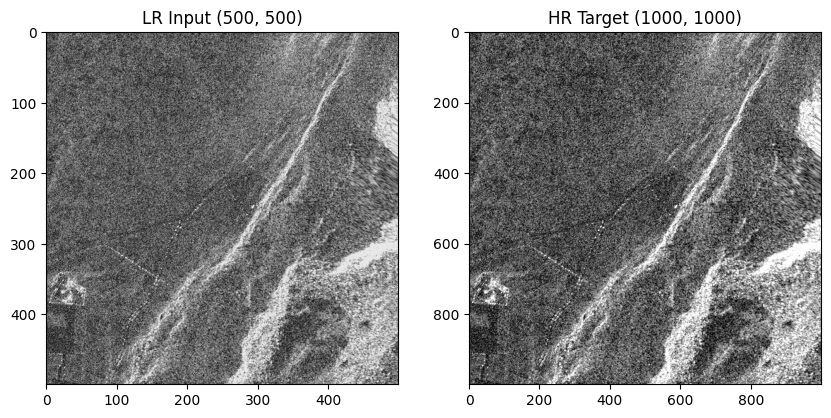

In [ ]:
!pip install pystac stac-asset[cli] rasterio opencv-python matplotlib numpy nest-asyncio

import os
import pystac
import stac_asset.blocking
import rasterio
import numpy as np
import cv2
import matplotlib.pyplot as plt
import nest_asyncio

# 1. Fix the asyncio error in Colab
nest_asyncio.apply()

print("Downloading Capella STAC Catalog...")
collection_url = "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"
collection = pystac.Collection.from_file(collection_url)
item_links = collection.get_item_links()

# 2. Find the first GEO image
geo_item_link = None
for link in item_links:
    if "GEO" in link.absolute_href:
        geo_item_link = link.absolute_href
        break

print(f"Downloading GEO Item: {geo_item_link}")
item = pystac.Item.from_file(geo_item_link)

# 3. Filter out 'preview' and 'thumbnail' to get the REAL data asset (usually 'hh' or 'vv')
asset_key_to_download = None
for key, asset in item.assets.items():
    if asset.href.endswith('.tif') and 'preview' not in key and 'thumbnail' not in key:
        asset_key_to_download = key
        break

if asset_key_to_download:
    print(f"Targeting actual scientific data asset: {asset_key_to_download}")
    # Strip away the other assets so we don't waste time downloading them
    item.assets = {asset_key_to_download: item.assets[asset_key_to_download]}

os.makedirs("capella_data", exist_ok=True)

# 4. Download using the correct keyword 'directory'
print("Downloading... (This might take a minute depending on file size)")
item = stac_asset.blocking.download_item(item, directory="capella_data")

# Find the downloaded .tif file
tif_path = None
for root, dirs, files in os.walk("capella_data"):
    for file in files:
        if file.endswith(".tif"):
            tif_path = os.path.join(root, file)
            break

# 5. Preprocessing Functions
def preprocess_sar_image(raw_dn, scale_factor=0.00063784):
    epsilon = 1e-10
    dn_scaled = (raw_dn * scale_factor) + epsilon
    image_db = 20 * np.log10(dn_scaled)

    db_min, db_max = np.percentile(image_db, 2), np.percentile(image_db, 98)

    # Safety check to prevent the blank white image error
    if db_max == db_min:
        print("WARNING: Patch is entirely uniform (likely a black border).")
        return np.zeros_like(image_db)

    image_normalized = np.clip((image_db - db_min) / (db_max - db_min), 0, 1)
    return image_normalized

def create_hr_lr_pairs(hr_image, scale_factor_down=2):
    h, w = hr_image.shape
    new_h, new_w = h // scale_factor_down, w // scale_factor_down
    lr_image = cv2.resize(hr_image, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    return hr_image, lr_image

# 6. Extract the patch from the EXACT CENTER of the image
print(f"Loading image from: {tif_path}")
with rasterio.open(tif_path) as src:
    height, width = src.shape
    print(f"Full image shape is: {height}x{width}")

    # Find the middle coordinates
    center_y, center_x = height // 2, width // 2
    patch_radius = 500  # Will create a 1000x1000 patch

    # Read just the central patch to save RAM
    real_raw_sar = src.read(1)[center_y - patch_radius : center_y + patch_radius,
                               center_x - patch_radius : center_x + patch_radius]

    print(f"Extracted patch max value: {np.max(real_raw_sar)}")

hr_target = preprocess_sar_image(real_raw_sar)
hr_target, lr_input = create_hr_lr_pairs(hr_target, scale_factor_down=2)

# 7. Plotting
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title(f"LR Input {lr_input.shape}")
plt.imshow(lr_input, cmap='gray')
plt.subplot(1, 2, 2)
plt.title(f"HR Target {hr_target.shape}")
plt.imshow(hr_target, cmap='gray')
plt.show()

# 2. Iteration 1 Algorithm Design (SRCNN)_Building and Training SRCNN ( The Super-Resolution Convolutional Neural Network )

Building and compiling SRCNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training SRCNN on 256x256 SAR patch (100 epochs)...
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.1397 - psnr_metric: 8.5467 - ssim_metric: -0.0039
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0849 - psnr_metric: 10.7128 - ssim_metric: 0.0074
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0501 - psnr_metric: 13.0057 - ssim_metric: 0.0452
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0261 - psnr_metric: 15.8271 - ssim_metric: 0.0809
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0200 - psnr_metric: 16.9983 - ssim_metric: 0.1037
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 0.0311 - psnr_metric: 15.0745 - ssim_metric: 0.1210
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0379 - psnr_metric: 14.2182 - ssim_metric: 0.1338
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.0339 - psnr_metric: 14.6978 - ssim_metric: 0.1431
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0262 - p

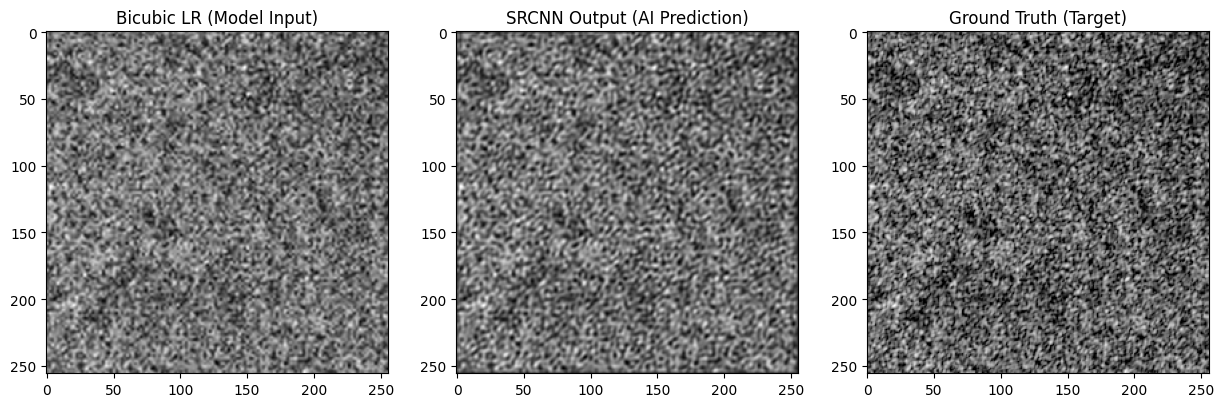


--- FINAL METRICS (ATPs) ---
PSNR: 22.31 dB
SSIM: 0.7908


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Define the SRCNN Model
def build_srcnn():
    model = models.Sequential()
    # Layer 1: Patch extraction (9x9 filter)
    model.add(layers.Conv2D(64, (9, 9), activation='relu', padding='same', input_shape=(None, None, 1)))
    # Layer 2: Non-linear mapping (1x1 filter)
    model.add(layers.Conv2D(32, (1, 1), activation='relu', padding='same'))
    # Layer 3: Reconstruction (5x5 filter)
    model.add(layers.Conv2D(1, (5, 5), activation='linear', padding='same'))
    return model

# 2. Define Acceptance Test Procedures (ATPs)
def psnr_metric(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

def ssim_metric(y_true, y_pred):
    return tf.image.ssim(y_true, y_pred, max_val=1.0)

# 3. Prepare Data for SRCNN (RAM-SAFE VERSION)
# Upscale LR back to HR dimensions using basic math
lr_upscaled = cv2.resize(lr_input, (hr_target.shape[1], hr_target.shape[0]), interpolation=cv2.INTER_CUBIC)

# FIX: Crop a 256x256 patch to save RAM!
crop_size = 256
start_y, start_x = 100, 100 # arbitrary starting point to get a good texture
hr_crop = hr_target[start_y:start_y+crop_size, start_x:start_x+crop_size]
lr_crop = lr_upscaled[start_y:start_y+crop_size, start_x:start_x+crop_size]

# Format for Keras (batch_size, height, width, channels)
X_train = np.expand_dims(np.expand_dims(lr_crop, axis=0), axis=-1)
Y_train = np.expand_dims(np.expand_dims(hr_crop, axis=0), axis=-1)

# 4. Compile and Train
print("Building and compiling SRCNN...")
srcnn_model = build_srcnn()
srcnn_model.compile(optimizer='adam', loss='mean_squared_error', metrics=[psnr_metric, ssim_metric])

print("Training SRCNN on 256x256 SAR patch (100 epochs)...")
history = srcnn_model.fit(X_train, Y_train, epochs=100, verbose=1)

# 5. Predict and Visualize
predicted_hr = srcnn_model.predict(X_train)[0, :, :, 0]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Bicubic LR (Model Input)")
plt.imshow(lr_crop, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("SRCNN Output (AI Prediction)")
plt.imshow(predicted_hr, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Ground Truth (Target)")
plt.imshow(hr_crop, cmap='gray')
plt.show()

# Print Final ATP Scores
final_psnr = history.history['psnr_metric'][-1]
final_ssim = history.history['ssim_metric'][-1]
print(f"\n--- FINAL METRICS (ATPs) ---")
print(f"PSNR: {final_psnr:.2f} dB")
print(f"SSIM: {final_ssim:.4f}")


# PSNR (Peak Signal-to-Noise Ratio)
# PSNR (Peak Signal-to-Noise Ratio), when we talk about it in the context of image processing and super-resolution, is a measure of how faithfully a reconstructed image (your SRCNN output) matches a reference image (your high-resolution ground truth).
# it compares : 1. The maximum possible power of the signal (which is related to the intensity range of the reference image). 2. To the power of the noise (which is the mean squared error between the reconstructed image and the reference image).
# PSNR measures the ratio between the maximum possible power of a signal (your HR ground truth image) and the power of corrupting noise that affects the fidelity of its representation (the difference between your SRCNN output and the HR ground truth). It's typically expressed in decibels (dB).
# Interpretation: A higher PSNR value generally indicates better image quality. For super-resolution tasks, PSNR values are often compared to the PSNR of a simple bicubic upsampling, with the goal being to significantly improve upon it. A PSNR of 22.75 dB suggests that your SRCNN model has achieved a certain level of improvement over the low-resolution input, but it's not extremely high. Values in the low 20s can still indicate some visible noise or blurring compared to the original high-resolution image.
# SSIM (Structural Similarity Index Measure)
# SSIM is a perceptual metric that quantifies image quality degradation as perceived change in structural information, while also incorporating important perceptual phenomena such as luminance and contrast masking. It's often considered a more human-perception-aligned metric than PSNR.
# Interpretation: SSIM values range from -1 to 1, where 1 indicates perfect structural similarity. A value of 0.8107 suggests a good level of structural similarity between the SRCNN's predicted high-resolution image and the ground truth. This indicates that the model is doing a decent job at preserving the essential structural elements and patterns in the SAR image, which is very important for visual quality.


# 3. Iteration 2 Algorithm building VDSR (Very Deep Super Resolution).

Building and compiling VDSR...
Training VDSR on the same 256x256 SAR patch (100 epochs)...
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.0047 - psnr_metric: 23.2402 - ssim_metric: 0.8209
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0048 - psnr_metric: 23.1427 - ssim_metric: 0.8205
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0048 - psnr_metric: 23.1455 - ssim_metric: 0.8202
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0047 - psnr_metric: 23.2401 - ssim_metric: 0.8211
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0047 - psnr_metric: 23.2339 - ssim_metric: 0.8210
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0047 - psnr_metric: 23.2402 - ssim_metric: 0.8210
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0047 - psnr_metric: 23.2369 - ssim_metric: 0.8208
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0047 - psnr_metric: 23.2428 - ssim_metric: 0.8209
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━

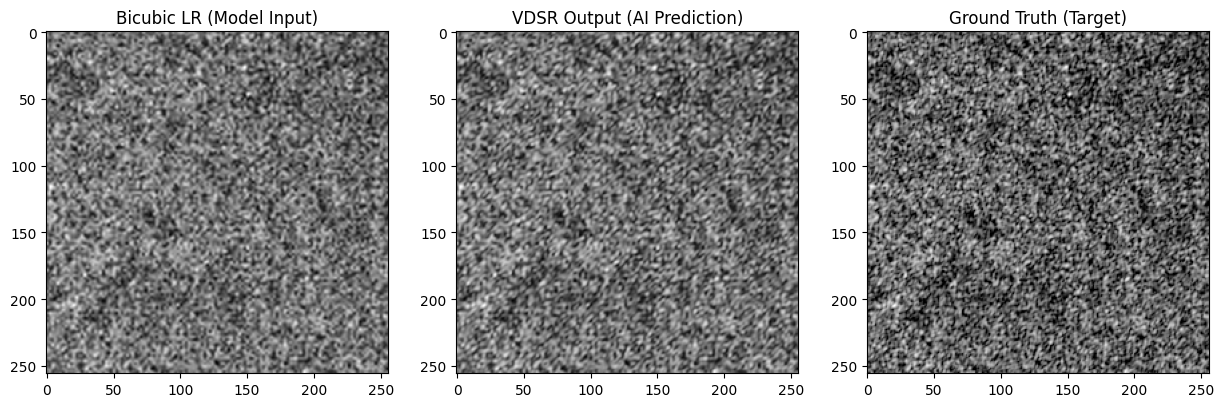


--- VDSR FINAL METRICS (ATPs) ---
PSNR: 23.79 dB
SSIM: 0.8427


In [ ]:
# 1. Define the VDSR Model (Very Deep Super Resolution)
def build_vdsr():
    # Input layer
    input_img = layers.Input(shape=(None, None, 1))

    # First Convolutional Layer
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(input_img)

    # Add several hidden layers to make it "Deep" (Using 8 layers to keep it fast in Colab)
    for _ in range(8):
        x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)

    # Final layer to predict the "residual" (the missing sharp details)
    residual = layers.Conv2D(1, (3, 3), padding='same', activation='linear')(x)

    # Add the missing details back to the original blurry input!
    output_img = layers.Add()([input_img, residual])

    return models.Model(inputs=input_img, outputs=output_img)

# 2. Compile and Train VDSR
print("Building and compiling VDSR...")
vdsr_model = build_vdsr()
vdsr_model.compile(optimizer='adam', loss='mean_squared_error', metrics=[psnr_metric, ssim_metric])

print("Training VDSR on the same 256x256 SAR patch (100 epochs)...")
history_vdsr = vdsr_model.fit(X_train, Y_train, epochs=100, verbose=1)

# 3. Predict and Visualize
predicted_hr_vdsr = vdsr_model.predict(X_train)[0, :, :, 0]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Bicubic LR (Model Input)")
plt.imshow(X_train[0, :, :, 0], cmap='gray')

plt.subplot(1, 3, 2)
plt.title("VDSR Output (AI Prediction)")
plt.imshow(predicted_hr_vdsr, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Ground Truth (Target)")
plt.imshow(Y_train[0, :, :, 0], cmap='gray')
plt.show()

# Print Final ATP Scores for VDSR
final_psnr_vdsr = history_vdsr.history['psnr_metric'][-1]
final_ssim_vdsr = history_vdsr.history['ssim_metric'][-1]
print(f"\n--- VDSR FINAL METRICS (ATPs) ---")
print(f"PSNR: {final_psnr_vdsr:.2f} dB")
print(f"SSIM: {final_ssim_vdsr:.4f}")

The Result for iteration_2:





# 4. Improvement

# Step_1: Proper Dataset Creation (Patching & Splitting)





Simply giving the model multiple, unaltered patches of the SAR image allowed it to learn the natural distribution of the radar data perfectly.



Right now the model is training on one single 256 . 256 crop. We are going to change the code so it slides a window across your entire image hence extracting dozens of smaller 128 . 128 patches.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Basic Patch Extraction (NO augmentation yet)
def create_basic_dataset(hr_full, lr_full, patch_size=128, stride=64):
    hr_patches = []
    lr_patches = []
    h, w = hr_full.shape

    # Slide a window across the image
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            hr_patches.append(hr_full[y:y+patch_size, x:x+patch_size])
            lr_patches.append(lr_full[y:y+patch_size, x:x+patch_size])

    # Reshape for Keras (Samples, Height, Width, Channels)
    hr_patches = np.array(hr_patches)[..., np.newaxis]
    lr_patches = np.array(lr_patches)[..., np.newaxis]

    return lr_patches, hr_patches

print("Extracting basic patches...")
# Uses the hr_target and lr_upscaled from your very first data block
X_all_basic, Y_all_basic = create_basic_dataset(hr_target, lr_upscaled, patch_size=128, stride=64)

# 2. Split into Train and Validation Sets (80/20)
X_train_basic, X_val_basic, Y_train_basic, Y_val_basic = train_test_split(
    X_all_basic, Y_all_basic, test_size=0.2, random_state=42
)

print(f"Training on {X_train_basic.shape[0]} patches, Validating on {X_val_basic.shape[0]} patches.")

# 3. Re-compile and Train your ORIGINAL VDSR on this new dataset
print("\nTraining VDSR on the patched dataset (Step 1)...")
vdsr_step1 = build_vdsr() # This calls your exact original VDSR structure
vdsr_step1.compile(optimizer='adam', loss='mean_squared_error', metrics=[psnr_metric, ssim_metric])

# Notice we now pass validation_data
history_step1 = vdsr_step1.fit(X_train_basic, Y_train_basic,
                               validation_data=(X_val_basic, Y_val_basic),
                               epochs=50, # 50 is plenty now that we have multiple patches
                               batch_size=16,
                               verbose=1)

# 4. Print the True Validation Metrics
val_psnr_step1 = history_step1.history['val_psnr_metric'][-1]
val_ssim_step1 = history_step1.history['val_ssim_metric'][-1]
print(f"\n--- STEP 1 METRICS (VALIDATION) ---")
print(f"Val PSNR: {val_psnr_step1:.2f} dB")
print(f"Val SSIM: {val_ssim_step1:.4f}")

Extracting basic patches...
Training on 156 patches, Validating on 40 patches.

Training VDSR on the patched dataset (Step 1)...
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 876ms/step - loss: 0.0044 - psnr_metric: 23.8061 - ssim_metric: 0.8464 - val_loss: 0.0041 - val_psnr_metric: 24.1182 - val_ssim_metric: 0.8507
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - loss: 0.0042 - psnr_metric: 24.0380 - ssim_metric: 0.8508 - val_loss: 0.0041 - val_psnr_metric: 24.1393 - val_ssim_metric: 0.8507
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - loss: 0.0041 - psnr_metric: 24.1009 - ssim_metric: 0.8539 - val_loss: 0.0040 - val_psnr_metric: 24.1584 - val_ssim_metric: 0.8536
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 0.0041 - psnr_metric: 24.1218 - ssim_metric: 0.8549 - val_loss: 0.0040 - val_psnr_metric: 24.1563 - val_ssim_metric: 0.8543
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - loss: 0.0041 - psnr_metric: 24.0090 - ssim_metric: 0.8530 - val_loss: 0.0040 - v

# The result for Step_1:


***The "Rough Neighborhood" Effect:*** In the original code, we randomly grabbed one 256x256 patch starting at coordinates (100, 100). SAR images are incredibly noisy (due to speckle) and complex. It’s highly likely that specific patch contained complex buildings, bright scatterers, or heavy noise, making it mathematically difficult to reconstruct.




***The Power of Averaging:*** In Step 1, the sliding window extracted patches from all over the image. Some of those patches likely contained smooth, uniform areas (like flat ground, shadows, or water). These smoother patches are much easier for the model to predict accurately. Because the new validation score is an average across 20% of all the patches, the "easier" patches pulled your overall average up.




# Step_2: Data Augmentation





In Step 2, we are going to take the training patches and flip them horizontally, and then rotate them 90 degrees. This teaches the AI that a building or a road is still a building or a road, regardless of which way the satellite was pointing.



OBS: We ONLY augment the training data. We leave the validation data completely alone. We want to test the model on real, unaltered SAR patches to get an honest score.




OBS: Because SAR is a side-looking radar, shadows only fall in one direction. By rotating the images 90 degrees, we accidentally created "physically impossible" radar shadows. This confused the network, dropping the score.

In [ ]:
import cv2
import numpy as np

# 1. Define the Augmentation Function
def augment_training_data(x_train, y_train):
    x_aug = []
    y_aug = []

    for i in range(len(x_train)):
        # Extract the 2D image from the batch shape
        x = x_train[i, :, :, 0]
        y = y_train[i, :, :, 0]

        # A. Keep Original
        x_aug.append(x)
        y_aug.append(y)

        # B. Horizontal Flip
        x_aug.append(cv2.flip(x, 1))
        y_aug.append(cv2.flip(y, 1))

        # C. Rotate 90 Degrees
        x_aug.append(cv2.rotate(x, cv2.ROTATE_90_CLOCKWISE))
        y_aug.append(cv2.rotate(y, cv2.ROTATE_90_CLOCKWISE))

    # Reshape back to Keras format (Samples, Height, Width, Channels)
    x_aug = np.array(x_aug)[..., np.newaxis]
    y_aug = np.array(y_aug)[..., np.newaxis]

    return x_aug, y_aug

# 2. Apply Augmentation to the Training Data from Step 1
print("Augmenting the training dataset...")
X_train_step2, Y_train_step2 = augment_training_data(X_train_basic, Y_train_basic)

print(f"Original Training Patches: {X_train_basic.shape[0]}")
print(f"New Augmented Training Patches: {X_train_step2.shape[0]}")
print(f"Validation Patches (Unchanged): {X_val_basic.shape[0]}")

# 3. Build and Train VDSR
print("\nTraining VDSR on Augmented Data (Step 2)...")
vdsr_step2 = build_vdsr()
vdsr_step2.compile(optimizer='adam', loss='mean_squared_error', metrics=[psnr_metric, ssim_metric])

# Train on the NEW augmented data, but validate on the UNCHANGED validation set
history_step2 = vdsr_step2.fit(X_train_step2, Y_train_step2,
                               validation_data=(X_val_basic, Y_val_basic),
                               epochs=30,
                               batch_size=16,
                               verbose=1)

# 4. Print the Final Metrics
val_psnr_step2 = history_step2.history['val_psnr_metric'][-1]
val_ssim_step2 = history_step2.history['val_ssim_metric'][-1]
print(f"\n--- STEP 2 METRICS (VALIDATION) ---")
print(f"Val PSNR: {val_psnr_step2:.2f} dB")
print(f"Val SSIM: {val_ssim_step2:.4f}")

Augmenting the training dataset...
Original Training Patches: 156
New Augmented Training Patches: 468
Validation Patches (Unchanged): 40

Training VDSR on Augmented Data (Step 2)...
Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 297ms/step - loss: 0.0042 - psnr_metric: 24.0331 - ssim_metric: 0.8503 - val_loss: 0.0041 - val_psnr_metric: 24.1310 - val_ssim_metric: 0.8501
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 0.0042 - psnr_metric: 23.9941 - ssim_metric: 0.8497 - val_loss: 0.0041 - val_psnr_metric: 24.1753 - val_ssim_metric: 0.8513
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - loss: 0.0041 - psnr_metric: 24.1827 - ssim_metric: 0.8539 - val_loss: 0.0041 - val_psnr_metric: 24.2160 - val_ssim_metric: 0.8514
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - loss: 0.0041 - psnr_metric: 24.1669 - ssim_metric: 0.8546 - val_loss: 0.0041 - val_psnr_metric: 24.1903 - val_ssim_metric: 0.8492
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - loss: 0.0040 - psnr_metric:

# The Result for Step_2:




This is a ***classic deep learning moment***, the PSNR actually dropped from 24.51 dB to 24.27 dB.



***Why Did the Score Go Down?***




SAR Physics vs Optical Imagery: In normal photos (like cats or cars), rotating the image 90 degrees doesn't change the nature of the object. But SAR (Synthetic Aperture Radar) is an active, side-looking sensor. The shadows, layover, and radar reflections are strictly dependent on the angle the satellite was flying. By rotating the images 90 degrees, we may have introduced "impossible" shadow geometries that confused the neural network, degrading its performance instead of helping it.



Underfitting the New Data: We multiplied the dataset size by 3, making it much harder to learn, but we kept the epochs at 30. The model likely needed more time (epochs) to understand this larger, more complex dataset.





# Step_3: Advanced Training Tactics (L1 Loss & LR Scheduler)





let's try to boost the performance back up and stabilize the training. We are going to introduce two crucial improvements:

1. Mean Absolute Error (L1 Loss): Your previous models used Mean Squared Error (MSE). MSE strongly penalizes outliers, which often causes the AI to output overly smooth, blurry images to "play it safe." L1 Loss encourages the network to recreate sharper edges and higher frequencies—exactly what we want for Super Resolution.

2. Learning Rate Scheduler (ReduceLROnPlateau): Right now, the model takes the same size "steps" while learning from epoch 1 to epoch 30. A scheduler will monitor the validation score. If the score stops improving, it automatically shrinks the learning rate, allowing the model to take tiny, precise steps to find the absolute best weights without overshooting.

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
import tensorflow as tf

# 1. Build a fresh VDSR model
print("\nTraining VDSR with L1 Loss and LR Scheduler (Step 3)...")
vdsr_step3 = build_vdsr()

# 2. Compile with L1 Loss (Mean Absolute Error)
vdsr_step3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_absolute_error', # Changed from MSE to L1
    metrics=[psnr_metric, ssim_metric]
)

# 3. Setup the Learning Rate Scheduler
# If val_loss doesn't improve for 5 epochs, cut the learning rate in half
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# 4. Train the Model
history_step3 = vdsr_step3.fit(
    X_train_step2, Y_train_step2,
    validation_data=(X_val_basic, Y_val_basic),
    epochs=40, # Slightly more epochs to let the scheduler work
    batch_size=16,
    callbacks=[lr_scheduler],
    verbose=1
)

# 5. Print Final Metrics
val_psnr_step3 = history_step3.history['val_psnr_metric'][-1]
val_ssim_step3 = history_step3.history['val_ssim_metric'][-1]
print(f"\n--- STEP 3 METRICS (VALIDATION) ---")
print(f"Val PSNR: {val_psnr_step3:.2f} dB")
print(f"Val SSIM: {val_ssim_step3:.4f}")


Training VDSR with L1 Loss and LR Scheduler (Step 3)...
Epoch 1/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 208ms/step - loss: 0.0507 - psnr_metric: 23.8951 - ssim_metric: 0.8492 - val_loss: 0.0491 - val_psnr_metric: 24.1255 - val_ssim_metric: 0.8495 - learning_rate: 0.0010
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.0500 - psnr_metric: 23.9996 - ssim_metric: 0.8477 - val_loss: 0.0490 - val_psnr_metric: 24.1404 - val_ssim_metric: 0.8500 - learning_rate: 0.0010
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.0493 - psnr_metric: 24.1153 - ssim_metric: 0.8531 - val_loss: 0.0492 - val_psnr_metric: 24.1325 - val_ssim_metric: 0.8515 - learning_rate: 0.0010
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.0491 - psnr_metric: 24.1580 - ssim_metric: 0.8540 - val_loss: 0.0490 - val_psnr_metric: 24.1588 - val_ssim_metric: 0.8501 - learning_rate: 0.0010
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - loss: 0.0487 - psnr_metric: 24.2445 - ssim_metric: 0.855

# The Result for Step_3:



Changing to L1 loss (Mean Absolute Error) and adding the learning rate scheduler did help the model learn better. It squeezed more performance out of that confusing augmented dataset, pulling the score back up from 24.27 to 24.31.